# Heart Disease Prediction — Exploratory Analysis


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/heart_disease_uci.csv')
df['target'] = (df['num'] > 0).astype(int)

for col in ['ca', 'thal', 'slope']:
    df[f'{col}_missing'] = df[col].isna().astype(int)

num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
cat_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal']

df_clean = df.copy()

for col in num_cols:
    df_clean[col] = df_clean.groupby('dataset')[col].transform(lambda x: x.fillna(x.median()))
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    mode_fill = lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    df_clean[col] = df_clean.groupby('dataset')[col].transform(mode_fill)
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode().iloc[0])



## 1. Correlation matrix

Correlation between numerical features and the target, to spot redundant variables and identify the strongest predictors.

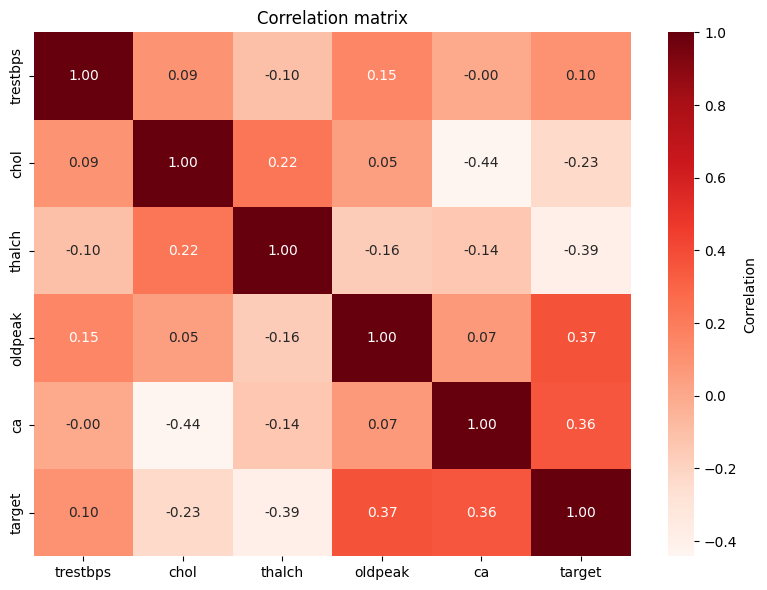

In [16]:
corr = df_clean[num_cols + ['target']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', cbar_kws={'label': 'Correlation'})
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=120)
plt.show()

## 2. Numerical variables vs target

Distribution of key numerical variables split by target, to see which ones separate healthy vs disease patients most clearly.


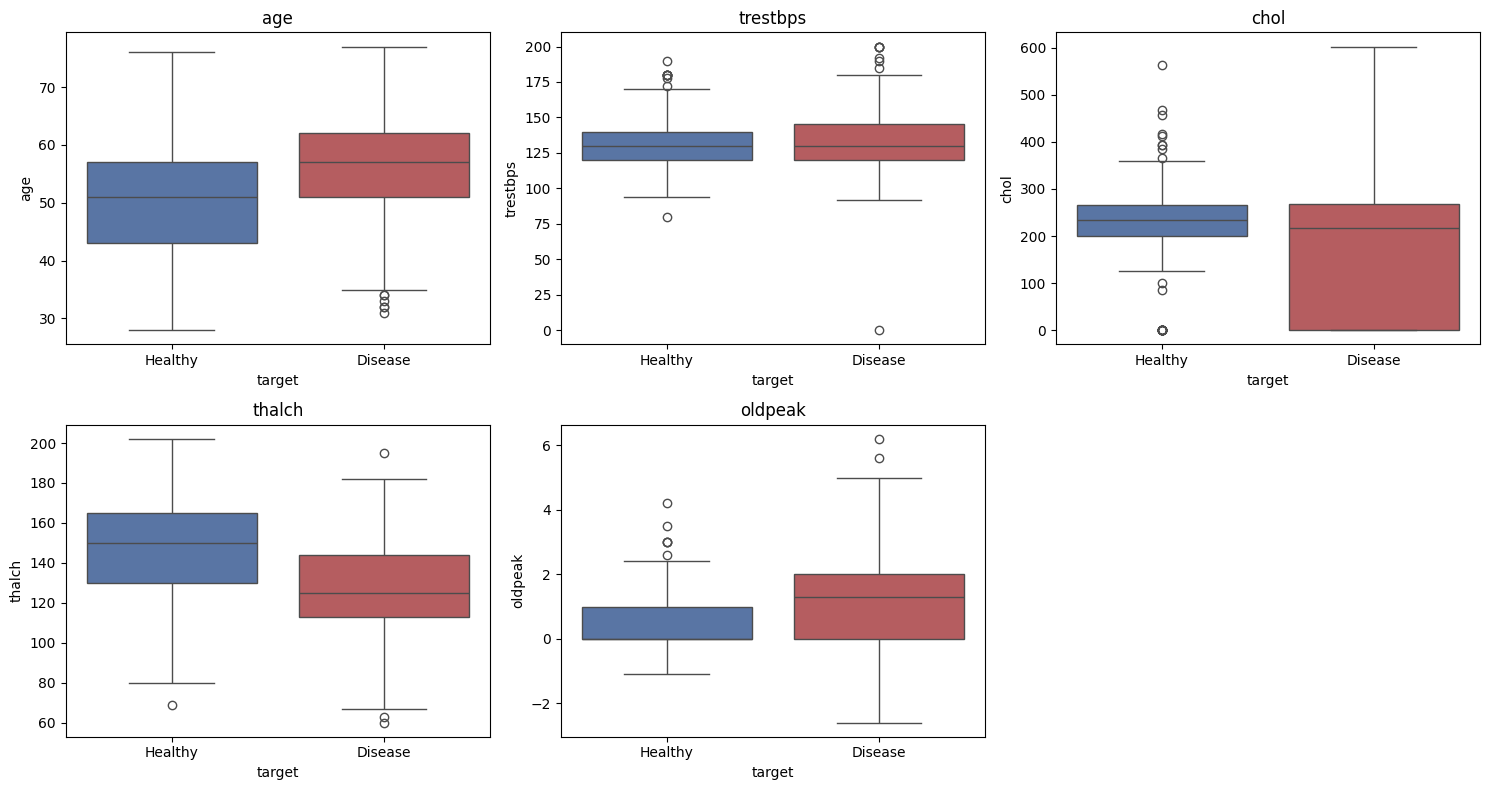

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(['age', 'trestbps', 'chol', 'thalch', 'oldpeak']):
    sns.boxplot(x='target', y=col, data=df_clean, ax=axes[i], hue='target', palette=['#4C72B0','#C44E52'], legend=False)
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Healthy', 'Disease'])

fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('../reports/figures/numerical_vs_target.png', dpi=120)
plt.show()

## 3. Categorical variables vs target

Proportion of disease within each category, to identify which categories are over-represented among diseased patients.



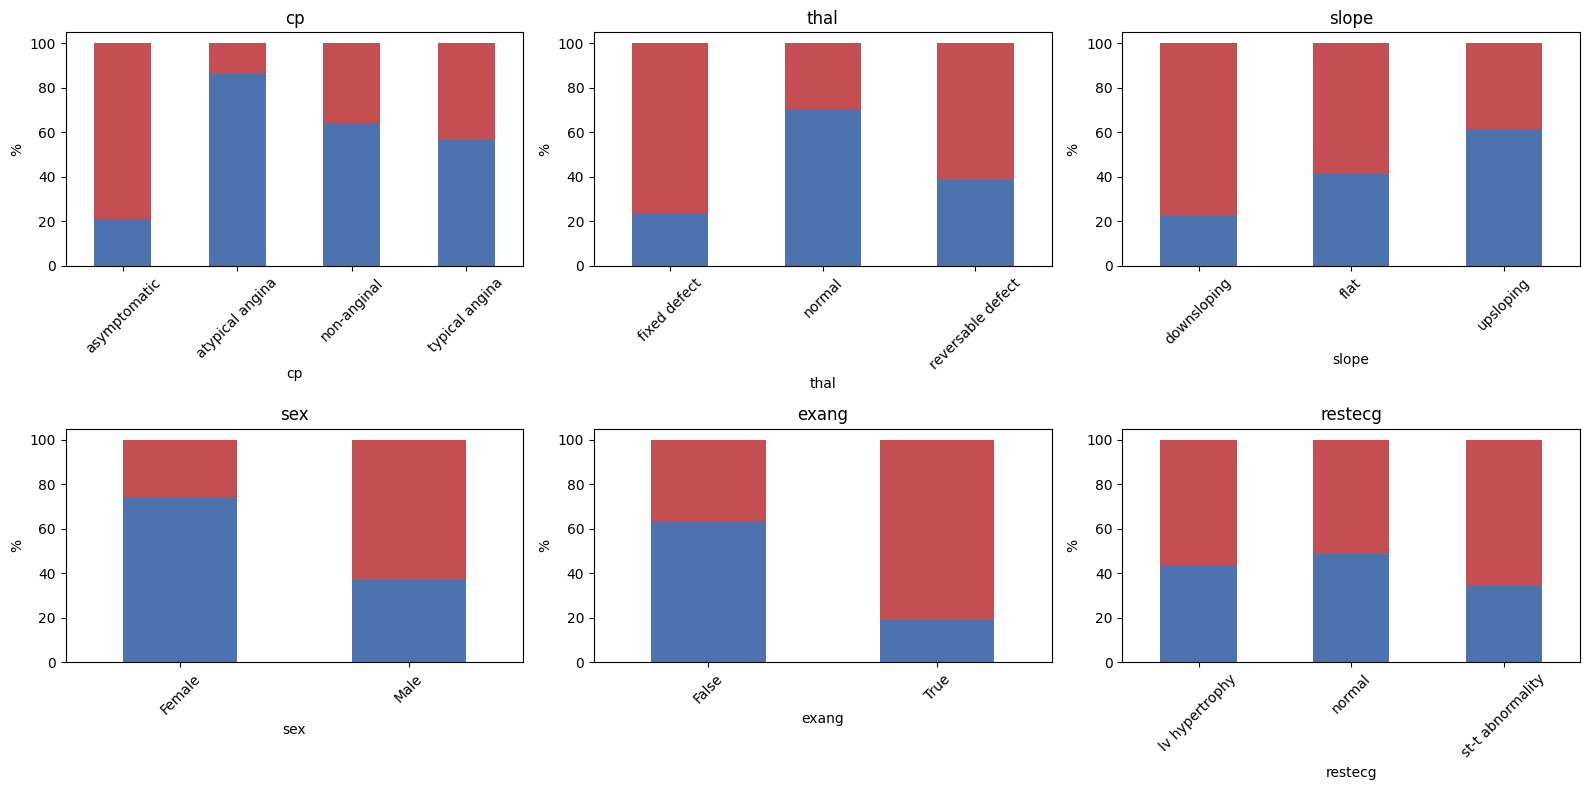

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(['cp', 'thal', 'slope', 'sex', 'exang', 'restecg']):
    pd.crosstab(df_clean[col], df_clean['target'], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=axes[i], color=['#4C72B0','#C44E52'], legend=False
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/categorical_vs_target.png', dpi=120)
plt.show()

## 4. Outlier detection

Boxplots of continuous numerical variables to spot extreme values before modeling.

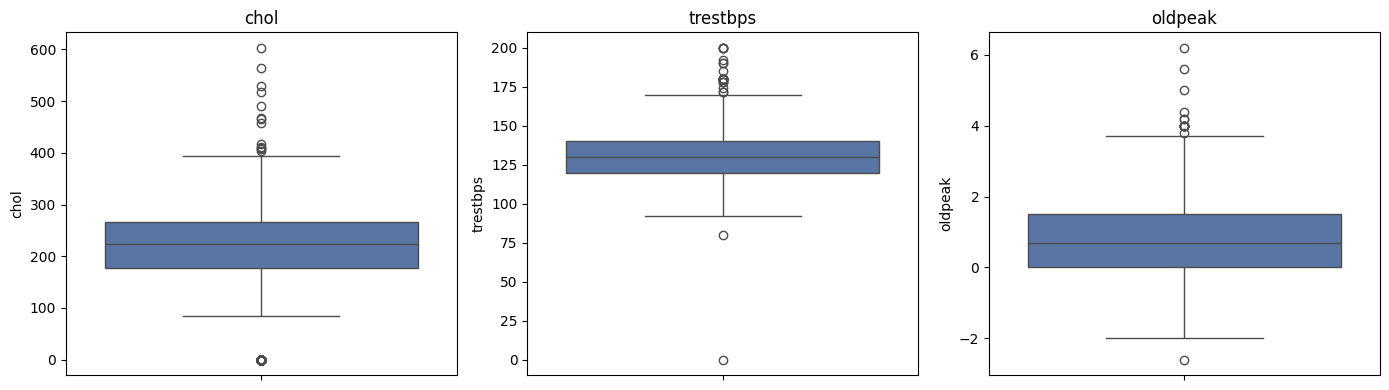

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['chol', 'trestbps', 'oldpeak']):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('../reports/figures/outliers.png', dpi=120)
plt.show()

## Summary

**Most discriminant variables**
- `oldpeak` (+0.37) and `ca` (+0.36) show the strongest correlation with target among numerical features.
- `thalch` (-0.39) is negatively correlated — lower max heart rate is associated with disease.
- `chol` (-0.23) is weakly negatively correlated, which is counter-intuitive and likely affected by the data quality issue below.
- Among categorical variables, `exang` (81% disease when True vs 37% when False), `thal` (76% disease for "fixed defect"), `slope` ("downsloping" → 78% disease) and `sex` (Male 62% vs Female 25%) show the clearest separation.

**Surprising finding**
- `cp` (chest pain type) is counter-intuitive: "asymptomatic" patients have the *highest* disease rate (~80%), while "atypical angina" patients have the *lowest* (~14%). This is a known pattern in this dataset — "asymptomatic" is a specific clinical category, not literally "no symptoms."

**Data quality issue found**
- `chol` and `trestbps` contain literal `0` values (not NaN) for some patients — physiologically impossible (zero cholesterol, zero blood pressure). These are almost certainly unmeasured values recorded as 0 instead of NaN in the original dataset, concentrated in specific hospitals. They were not caught by our missingness handling in Phase 1 since they weren't NaN.
- **Action needed**: revisit Phase 1 to treat `chol == 0` and `trestbps == 0` as missing, then re-impute, before moving to modeling — otherwise these act as extreme outliers and bias the median/mode imputation and any model that includes them.